# Tiền xử lý dữ liệu DKA-AKI

## Bài toán
Dự đoán nguy cơ **tổn thương thận cấp (AKI)** ở bệnh nhân **nhiễm toan ceton do đái tháo đường (DKA)** trong vòng 1 tuần nhập ICU — phân loại nhị phân với nhãn `akdPositive`.

Dữ liệu từ MIMIC-IV, theo bài báo Fan T. và cộng sự (2023), *Front. Public Health* 11:1087297. Ý nghĩa từng trường và lý do chọn cách tổng hợp chuỗi thời gian: xem `project/docs/data_dictionary.md`.

Notebook này **tiền xử lý tập `train.json`** kèm **phân tích khám phá (EDA)**. Các hàm viết tổng quát để tái dùng cho `test.json`.

## 1. Thư viện sử dụng

`numpy`/`pandas` xử lý bảng; `matplotlib`/`seaborn` vẽ EDA; `scikit-learn` để điền thiếu (`KNNImputer`) và chuẩn hoá (`StandardScaler`); `joblib` lưu bộ tiền xử lý.

In [1]:
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
import joblib

sns.set_theme(style='whitegrid')
%matplotlib inline

## 2. Đọc dữ liệu

Đường dẫn tương đối so với notebook (`project/src/` → dữ liệu ở `project/data/`). Mỗi bản ghi là một lần nằm ICU: các mã định danh, nhãn `akdPositive`, và `measures` chứa các chỉ số.

In [2]:
DATA_DIR = os.path.join('..', 'data')
with open(os.path.join(DATA_DIR, 'train.json'), encoding='utf-8') as f:
    train = json.load(f)

print('Số bản ghi train:', len(train))
print('Các khóa cấp cao nhất:', list(train[0].keys()))

Số bản ghi train: 970
Các khóa cấp cao nhất: ['subjectId', 'hadmId', 'stayId', 'akdPositive', 'measures']


**Nhận xét:** **970 bản ghi**, mỗi bản ghi gồm 3 mã định danh, nhãn `akdPositive`, và `measures`.

Xem nhanh một chỉ số vô hướng và một chỉ số chuỗi thời gian:

In [3]:
m = train[0]['measures']
print('age (vô hướng):', m['age'])
print('bun (chuỗi thời gian) — vài thời điểm đầu:')
for t, v in list(m['bun'].items())[:4]:
    print('   ', t, '->', v)

age (vô hướng): 48
bun (chuỗi thời gian) — vài thời điểm đầu:
    2133-01-25T04:39:00 -> 39.0
    2133-01-25T10:10:00 -> 36.0
    2133-01-25T14:05:00 -> 38.0
    2133-01-25T18:00:00 -> 39.0


**Nhận xét:** chỉ số vô hướng là **một giá trị**; chỉ số như `bun` là **từ điển `{thời điểm: giá trị}`** — đo nhiều lần trong 24h đầu. Đây là điểm mấu chốt cần xử lý (mục 4).

## 3. Phân loại đặc trưng tĩnh (static) / động (dynamic)

- **Tĩnh**: một giá trị/bệnh nhân. **Động**: chuỗi thời gian đo nhiều lần.
Tự phân loại dựa trên việc giá trị có phải `dict` hay không.

In [4]:
scalar_keys, ts_keys = set(), set()
for r in train:
    for k, v in r['measures'].items():
        (ts_keys if isinstance(v, dict) else scalar_keys).add(k)
print('ĐỘNG (%d):' % len(ts_keys), sorted(ts_keys))
print('\nTĨNH (%d):' % len(scalar_keys), sorted(scalar_keys))

ĐỘNG (17): ['ag', 'bg', 'bicarbonate', 'bun', 'calcium', 'dbp', 'gcs', 'gcs_unable', 'hb', 'hr', 'phosphate', 'plt', 'rr', 'sbp', 'scr', 'wbc', 'weight']

TĨNH (20): ['age', 'chronic_pulmonary_disease', 'ckd_stage', 'congestive_heart_failure', 'dka_type', 'egfr', 'gender', 'history_aci', 'history_ami', 'hypertension', 'liver_disease', 'macroangiopathy', 'malignant_cancer', 'microangiopathy', 'oasis', 'preiculos', 'race', 'saps2', 'sofa', 'uti']


**Nhận xét:** **17 đặc trưng động** (sinh hiệu + xét nghiệm) và **20 đặc trưng tĩnh**. Khớp từ điển dữ liệu.

## 4. Tổng hợp chuỗi thời gian về một dòng/bệnh nhân

Mỗi đặc trưng động có nhiều giá trị theo thời gian (sinh hiệu trung bình ~60 lần đo, xét nghiệm ~4 lần) nhưng mô hình cần **một dòng/bệnh nhân**. Các lựa chọn:

| Phương án | Ưu | Nhược |
|---|---|---|
| Giá trị **đầu tiên** (bài báo) | Đơn giản, là trạng thái lúc nhập viện | Bỏ phí phần lớn dữ liệu; nhạy với 1 lần đo |
| Giá trị **cuối** | Trạng thái gần thời điểm dự đoán | Vẫn mất thông tin diễn biến |
| **Trung bình / trung vị** | Ổn định, ít nhiễu | **Che mất cực trị** quan trọng |
| **{min, mean, max}** ✅ | Giữ cả mức nền lẫn cực trị | Nhiều cột hơn (×3), hơi dư thừa |
| Toàn bộ thống kê + độ dốc | Giàu thông tin nhất | Quá nhiều cột, dễ overfit với 970 mẫu |

**Lựa chọn: `{min, mean, max}`** cho mỗi đặc trưng động. Lý do (xem thêm data dictionary):
- Trong AKI, **cực trị mới mang nhiều thông tin** (creatinine/BUN đỉnh, huyết áp thấp nhất do giảm tưới máu thận).
- Ví dụ rõ nhất — tương quan của `sbp` với nhãn: **min = −0.26, mean = +0.05, max = +0.27**. Nếu chỉ lấy trung bình thì tín hiệu gần như **biến mất**, còn min/max lại rất rõ và ngược chiều nhau.
- Sinh hiệu có ~60 lần đo/bệnh nhân ⇒ lấy 1 giá trị là lãng phí.
- Đúng tinh thần bài báo: tạo nhiều đặc trưng ứng viên rồi để bước chọn đặc trưng (LASSO) lọc lại.

In [5]:
TS_KEYS = ['hr', 'rr', 'gcs', 'gcs_unable', 'dbp', 'sbp', 'ag', 'bg', 'bicarbonate',
           'bun', 'scr', 'phosphate', 'calcium', 'weight', 'plt', 'hb', 'wbc']
NUM_SCALAR = ['age', 'oasis', 'saps2', 'sofa', 'preiculos', 'egfr']
CATEG = ['gender', 'race', 'liver_disease', 'dka_type']
ALWAYS_BOOL = ['chronic_pulmonary_disease', 'congestive_heart_failure', 'malignant_cancer']
COMORBID_FLAGS = ['hypertension', 'microangiopathy', 'macroangiopathy',
                  'history_ami', 'uti', 'history_aci']
CKD = 'ckd_stage'
TARGET = 'akdPositive'
STATS = ['min', 'mean', 'max']

def agg_series(ts):
    """Tổng hợp một chuỗi thời gian thành (min, mean, max). Mọi thời điểm đều trong 24h đầu."""
    a = np.array(list(ts.values()), dtype=float)
    return np.nanmin(a), np.nanmean(a), np.nanmax(a)

def flatten(record):
    """Chuyển một bản ghi bệnh nhân thành một dòng đặc trưng phẳng."""
    m = record['measures']
    row = {'subjectId': record['subjectId'], 'hadmId': record['hadmId'], 'stayId': record['stayId']}
    if TARGET in record:
        row[TARGET] = int(record[TARGET])
    for k in TS_KEYS:
        v = m.get(k)
        vals = agg_series(v) if isinstance(v, dict) and len(v) > 0 else (np.nan, np.nan, np.nan)
        for s, val in zip(STATS, vals):
            row[f'{k}_{s}'] = val
    for k in NUM_SCALAR + CATEG:
        row[k] = m.get(k, np.nan)
    for k in ALWAYS_BOOL + COMORBID_FLAGS:
        row[k] = int(bool(m.get(k, False)))   # cờ bệnh nền: vắng mặt -> 0
    row[CKD] = m.get(CKD, 0)                   # vắng mặt -> 0 (không CKD)
    return row

## 5. Tạo DataFrame đặc trưng

In [6]:
df = pd.DataFrame([flatten(r) for r in train])
# Cot so = (min/mean/max cua tung dac trung dong) + cac vo huong so
numeric_cols = [f'{k}_{s}' for k in TS_KEYS for s in STATS] + NUM_SCALAR
print('Kích thước bảng:', df.shape)
print('Số cột số (đã tổng hợp):', len(numeric_cols))
df.head()

Kích thước bảng: (970, 75)
Số cột số (đã tổng hợp): 57


,subjectId,hadmId,stayId,akdPositive,hr_min,hr_mean,hr_max,rr_min,rr_mean,rr_max,...,chronic_pulmonary_disease,congestive_heart_failure,malignant_cancer,hypertension,microangiopathy,macroangiopathy,history_ami,uti,history_aci,ckd_stage
0,13980145,27684437,31863678,1,82.0,102.500000,125.0,11.0,24.971098,40.0,...,0,0,0,1,1,0,0,0,0,0
1,17023850,22809440,36788943,0,70.0,82.160000,93.0,11.0,15.800000,21.0,...,0,0,0,0,0,0,0,0,0,0
2,16815664,25402575,37650557,0,78.0,102.204082,135.0,11.0,18.020408,30.0,...,0,0,0,0,0,0,0,0,0,0
3,13286912,25359629,36271811,1,62.0,87.549844,110.0,7.0,18.872881,55.0,...,0,0,0,0,1,1,0,0,0,0
4,19400460,27782205,30012944,0,75.0,89.933333,111.0,13.0,20.666667,31.0,...,0,0,0,0,0,0,0,0,0,0


**Nhận xét:** mỗi đặc trưng động sinh 3 cột (`*_min`, `*_mean`, `*_max`) ⇒ 17×3 = **51 cột động** + 6 vô hướng số = **57 cột số**, cùng các cột phân loại/bệnh nền. (Lưu ý: `weight` chỉ ~1 lần đo nên min=mean=max — hơi dư thừa nhưng vô hại, bước chọn đặc trưng sẽ tự loại.)

## 6. Phân tích khám phá dữ liệu (EDA)

Tìm hiểu: nhãn cân bằng không, biến số phân bố ra sao, có ngoại lai không, biến nào liên quan AKI.

### 6.1 Phân bố nhãn

akdPositive
0    593
1    377
Name: count, dtype: int64
Tỉ lệ dương tính: 38.9%


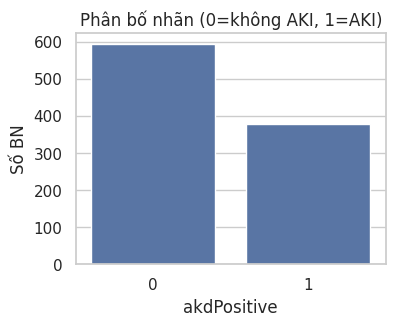

In [7]:
print(df[TARGET].value_counts().sort_index())
print('Tỉ lệ dương tính: {:.1%}'.format(df[TARGET].mean()))
plt.figure(figsize=(4, 3))
sns.countplot(x=TARGET, data=df)
plt.title('Phân bố nhãn (0=không AKI, 1=AKI)'); plt.xlabel('akdPositive'); plt.ylabel('Số BN')
plt.show()

**Nhận xét:** **377 dương / 593 âm (≈ 38.9%)** — mất cân bằng nhẹ. Khi huấn luyện nên chia train/validation **theo phân tầng (stratify)** và đánh giá bằng **AUC/F1** thay vì chỉ accuracy.

### 6.2 Thống kê mô tả (xem cột `*_mean` + vô hướng cho gọn)

In [8]:
mean_cols = [f'{k}_mean' for k in TS_KEYS]
df[mean_cols + NUM_SCALAR].describe().T[['mean', 'std', 'min', '50%', 'max']].round(1)

,mean,std,min,50%,max
hr_mean,91.0,12.6,51.9,90.8,148.6
rr_mean,19.1,3.4,9.4,18.6,35.9
gcs_mean,14.6,1.0,3.0,15.0,15.0
gcs_unable_mean,0.1,0.3,0.0,0.0,1.0
dbp_mean,69.2,11.0,29.0,69.1,104.8
sbp_mean,124.4,16.4,59.0,122.3,180.5
ag_mean,16.4,3.8,5.5,16.0,42.3
bg_mean,229.0,83.2,70.0,212.8,818.0
bicarbonate_mean,18.4,4.3,5.1,18.5,34.8
bun_mean,24.2,19.1,1.8,17.6,119.7


**Nhận xét:** khoảng giá trị **hợp lý về mặt lâm sàng** cho bệnh nhân DKA nặng (vd đường huyết rất cao, chức năng thận biến thiên mạnh). Không có giá trị vô lý (âm/sai đơn vị) ⇒ **không cần cắt ngoại lai mạnh**. Nhiều biến **lệch phải**, củng cố việc nên chuẩn hoá.

### 6.3 Phân phối một số biến quan trọng

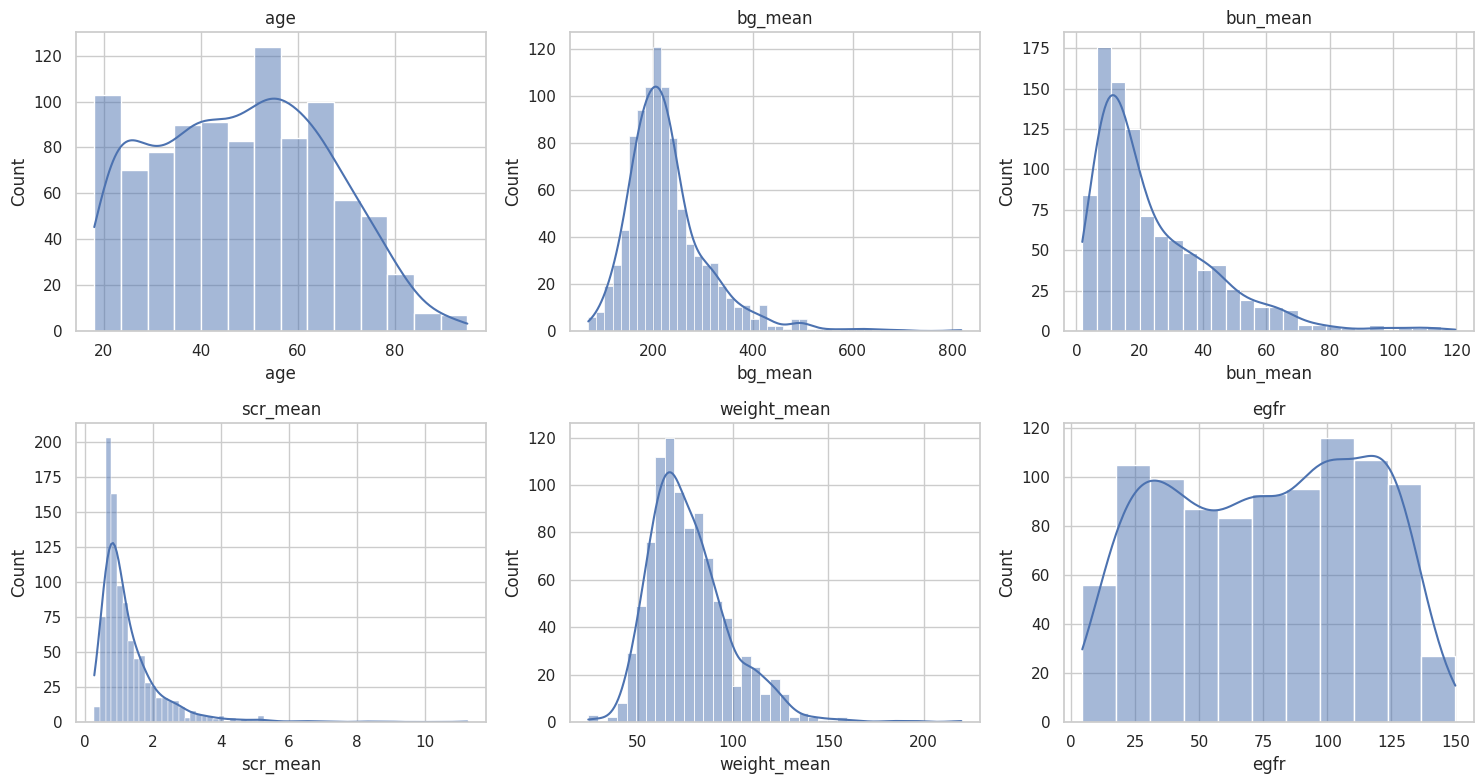

In [9]:
feat_show = ['age', 'bg_mean', 'bun_mean', 'scr_mean', 'weight_mean', 'egfr']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), feat_show):
    sns.histplot(df[col].dropna(), kde=True, ax=ax); ax.set_title(col)
plt.tight_layout(); plt.show()

**Nhận xét:** `bg`, `bun`, `scr` **lệch phải** mạnh (đuôi dài về giá trị cao); `age` trải rộng. Phù hợp với việc chuẩn hoá.

### 6.4 So sánh nhóm AKI vs không AKI

Trung vị theo nhóm (0=không AKI, 1=AKI):
akdPositive      0      1
bun_mean      13.7   29.2
bun_max       17.0   33.0
scr_mean       0.8    1.3
age           42.0   58.0
weight_mean   68.7   81.6
egfr          95.2   47.7
bg_max       297.0  329.0


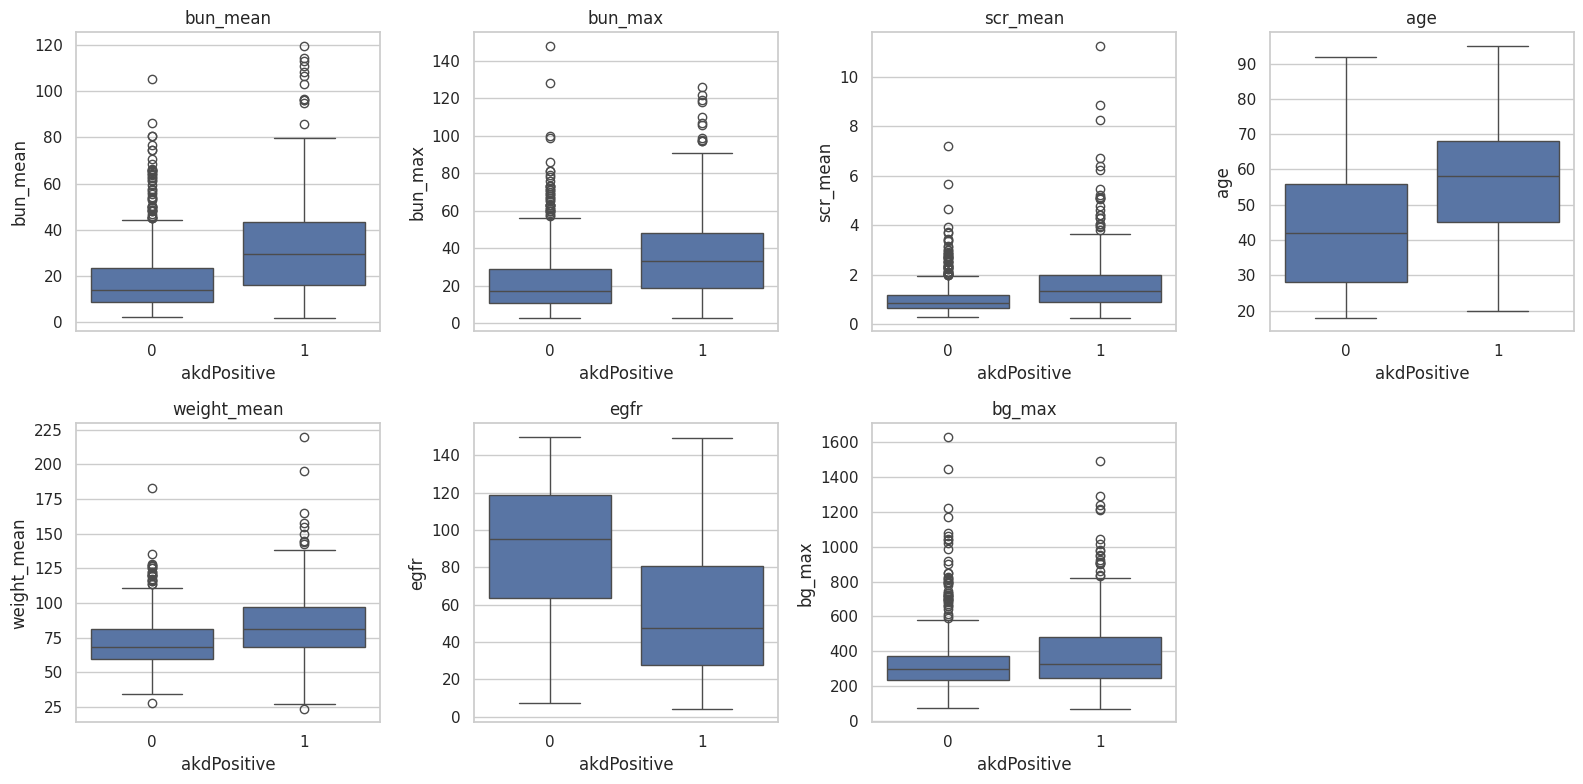

In [10]:
key_feats = ['bun_mean', 'bun_max', 'scr_mean', 'age', 'weight_mean', 'egfr', 'bg_max']
print('Trung vị theo nhóm (0=không AKI, 1=AKI):')
print(df.groupby(TARGET)[key_feats].median().round(1).T)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.ravel(), key_feats):
    sns.boxplot(x=TARGET, y=col, data=df, ax=ax); ax.set_title(col)
axes.ravel()[-1].axis('off')
plt.tight_layout(); plt.show()

**Nhận xét:** nhóm AKI (trung vị): `bun_mean` **13.7 → 29.2**, `bun_max` **17 → 33**, `scr_mean` **0.8 → 1.3** (thận xấu hơn), `age` **42 → 58** (lớn tuổi hơn), `weight_mean` **68.7 → 81.6 kg** (nặng cân hơn), `egfr` **95.2 → 47.7** (giảm mạnh), `bg_max` **297 → 329**. Đúng với bài báo: **BUN, cân nặng, tuổi** là các yếu tố quan trọng.

### 6.5 Tương quan của biến số với nhãn (top 20)

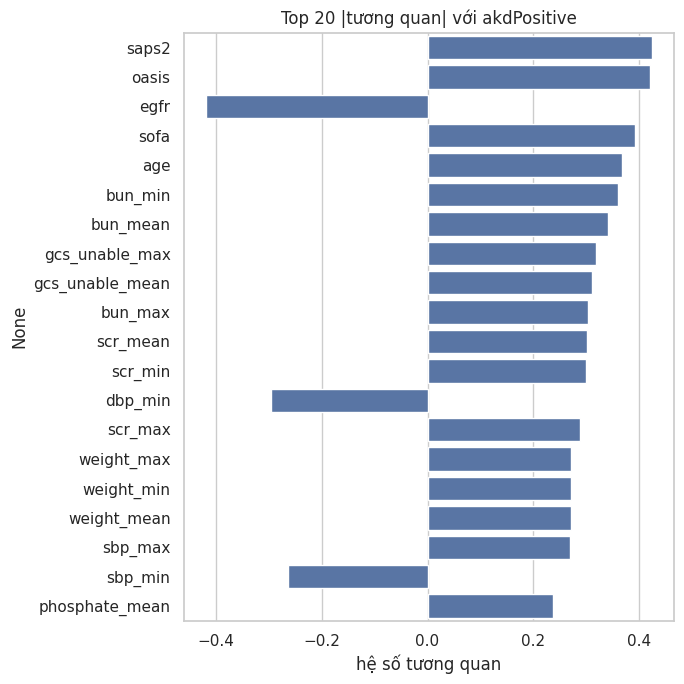

saps2              0.423
oasis              0.421
egfr              -0.418
sofa               0.391
age                0.367
bun_min            0.359
bun_mean           0.340
gcs_unable_max     0.319
gcs_unable_mean    0.311
bun_max            0.304
scr_mean           0.302
scr_min            0.300
dbp_min           -0.295
scr_max            0.288
weight_max         0.271
weight_min         0.271
weight_mean        0.271
sbp_max            0.268
sbp_min           -0.263
phosphate_mean     0.236
Name: akdPositive, dtype: float64

In [11]:
corr = df[numeric_cols + [TARGET]].corr()[TARGET].drop(TARGET)
corr = corr.reindex(corr.abs().sort_values(ascending=False).index)
top = corr.head(20)
plt.figure(figsize=(7, 7))
sns.barplot(x=top.values, y=top.index)
plt.title('Top 20 |tương quan| với akdPositive'); plt.xlabel('hệ số tương quan'); plt.tight_layout()
plt.show()
top.round(3)

**Nhận xét:** mạnh nhất là **điểm độ nặng** (`saps2`, `oasis`, `sofa` ≈ 0.39–0.42), `egfr` **âm** (≈ −0.42, eGFR thấp ⇒ nguy cơ cao), rồi `age`, `bun_*`, `scr_*`, `weight`, `gcs_unable_max`. Đáng chú ý `sbp_max` (+0.27) và `dbp_min` (−0.30) đều lọt top — minh chứng việc giữ **cực trị** (min/max) là quyết định đúng, vì giá trị trung bình của huyết áp gần như không tương quan.

### 6.6 Biến phân loại & bệnh nền

gender -> {'F': 521, 'M': 449}
dka_type -> {1: 600, 2: 275, 0: 95}
liver_disease -> {'NONE': 880, 'MILD': 70, 'SEVERE': 20}
race: số nhãn gốc = 23


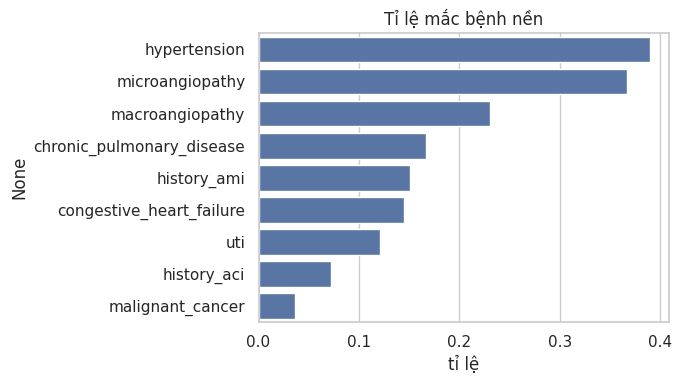

hypertension                 39.0
microangiopathy              36.7
macroangiopathy              23.1
chronic_pulmonary_disease    16.7
history_ami                  15.1
congestive_heart_failure     14.5
uti                          12.1
history_aci                   7.2
malignant_cancer              3.6
dtype: float64

In [12]:
for c in ['gender', 'dka_type', 'liver_disease']:
    print(c, '->', dict(df[c].value_counts()))
print('race: số nhãn gốc =', df['race'].nunique())
flag_cols = ALWAYS_BOOL + COMORBID_FLAGS
prev = df[flag_cols].mean().sort_values(ascending=False)
plt.figure(figsize=(7, 4))
sns.barplot(x=prev.values, y=prev.index)
plt.title('Tỉ lệ mắc bệnh nền'); plt.xlabel('tỉ lệ'); plt.tight_layout(); plt.show()
(prev * 100).round(1)

**Nhận xét:** giới khá cân bằng; `dka_type` chủ yếu T1DM (`1`); `liver_disease` đa số `NONE`; `race` có **23 nhãn gốc** ⇒ cần gộp nhóm. Bệnh nền phổ biến nhất là tăng huyết áp/bệnh vi mạch; nhiều cờ khác hiếm.

## 7. Kiểm tra giá trị thiếu

Bài báo loại đặc trưng **thiếu > 20%**. Cờ bệnh nền đã điền 0 ở bước flatten nên không còn thiếu.

In [13]:
ID_COLS = ['subjectId', 'hadmId', 'stayId']
feature_cols = [c for c in df.columns if c not in ID_COLS + [TARGET]]
missing = df[feature_cols].isnull().mean().sort_values(ascending=False)
print('Tỉ lệ thiếu (các cột > 0%):')
print((missing[missing > 0] * 100).round(2).astype(str) + '%')

Tỉ lệ thiếu (các cột > 0%):
wbc_min             5.88%
wbc_mean            5.88%
wbc_max             5.88%
hb_mean             5.88%
hb_min              5.88%
hb_max              5.88%
plt_max             5.67%
plt_mean            5.67%
plt_min             5.67%
weight_max          1.65%
weight_mean         1.65%
weight_min          1.65%
calcium_max         1.03%
calcium_min         1.03%
calcium_mean        1.03%
phosphate_max       0.93%
phosphate_min       0.93%
phosphate_mean      0.93%
bicarbonate_min     0.52%
bg_max              0.52%
bg_mean             0.52%
bg_min              0.52%
ag_max              0.52%
ag_mean             0.52%
ag_min              0.52%
bicarbonate_mean    0.52%
scr_max             0.52%
scr_mean            0.52%
scr_min             0.52%
bun_max             0.52%
bun_mean            0.52%
bun_min             0.52%
bicarbonate_max     0.52%
egfr                0.52%
sbp_min             0.31%
dbp_min             0.31%
dbp_mean            0.31%
sbp_max   

**Nhận xét:** chỉ các chỉ số xét nghiệm/sinh hiệu thiếu, đều **< 6%**; các cột `*_min/_mean/_max` của cùng một chỉ số thiếu cùng tỉ lệ (vì thiếu cả chuỗi). Cờ bệnh nền **0% thiếu** (vắng = 0 là đúng lâm sàng). ⇒ **không đặc trưng đo lường nào vượt 20%**.

## 8. Loại đặc trưng > 20% và điền KNN

Điền các cột số còn thiếu bằng `KNNImputer` (lấy trung bình các bệnh nhân giống nhất — đúng tinh thần *nearest neighbor* của bài báo).

In [14]:
to_drop = missing[missing > 0.20].index.tolist()
print('Đặc trưng bị loại (>20%):', to_drop if to_drop else '(không có)')
df = df.drop(columns=to_drop)
numeric_cols = [c for c in numeric_cols if c in df.columns]

imputer = KNNImputer(n_neighbors=5)
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])
print('Số giá trị thiếu còn lại ở cột số:', int(df[numeric_cols].isnull().sum().sum()))

Đặc trưng bị loại (>20%): (không có)
Số giá trị thiếu còn lại ở cột số: 0


**Nhận xét:** không cột nào bị loại; sau KNN, **không còn giá trị thiếu**. `imputer` được lưu để áp dụng y hệt cho test.

## 9. Mã hóa biến phân loại

`gender` F/M→0/1; `liver_disease` NONE/MILD/SEVERE→0/1/2 (có thứ tự); `race` gộp 23→5 nhóm rồi one-hot; `dka_type` 1/2/0→T1DM/T2DM/Other rồi one-hot.

In [15]:
df['gender'] = df['gender'].map({'F': 0, 'M': 1}).astype(int)
df['liver_disease'] = df['liver_disease'].map({'NONE': 0, 'MILD': 1, 'SEVERE': 2}).astype(int)

def group_race(s):
    s = str(s).upper()
    if 'WHITE' in s:
        return 'White'
    if 'BLACK' in s or 'AFRICAN' in s:
        return 'Black'
    if 'HISPANIC' in s or 'LATINO' in s:
        return 'Hispanic'
    if 'ASIAN' in s:
        return 'Asian'
    return 'Other'

df['race_group'] = df['race'].apply(group_race)
df = df.drop(columns=['race'])
df['dka_type'] = df['dka_type'].map({1: 'T1DM', 2: 'T2DM', 0: 'Other'}).fillna('Other')
df = pd.get_dummies(df, columns=['race_group', 'dka_type'], prefix=['race', 'dka'])
df[df.select_dtypes(include='bool').columns] = df.select_dtypes(include='bool').astype(int)
print('Số cột sau mã hoá:', df.shape[1])
df.head()

Số cột sau mã hoá: 81


,subjectId,hadmId,stayId,akdPositive,hr_min,hr_mean,hr_max,rr_min,rr_mean,rr_max,...,history_aci,ckd_stage,race_Asian,race_Black,race_Hispanic,race_Other,race_White,dka_Other,dka_T1DM,dka_T2DM
0,13980145,27684437,31863678,1,82.0,102.500000,125.0,11.0,24.971098,40.0,...,0,0,0,0,0,0,1,0,1,0
1,17023850,22809440,36788943,0,70.0,82.160000,93.0,11.0,15.800000,21.0,...,0,0,0,0,0,0,1,0,1,0
2,16815664,25402575,37650557,0,78.0,102.204082,135.0,11.0,18.020408,30.0,...,0,0,0,1,0,0,0,0,1,0
3,13286912,25359629,36271811,1,62.0,87.549844,110.0,7.0,18.872881,55.0,...,0,0,0,0,0,0,1,0,1,0
4,19400460,27782205,30012944,0,75.0,89.933333,111.0,13.0,20.666667,31.0,...,0,0,1,0,0,0,0,0,1,0


**Nhận xét:** mọi cột giờ đều là **số**. `race`→5 cột `race_*`, `dka_type`→3 cột `dka_*`. Sẵn sàng chuẩn hoá.

## 10. Chuẩn hóa đặc trưng số

`StandardScaler` cho các cột số liên tục (quan trọng với mô hình tuyến tính/SVM/NN; cây như XGBoost không bắt buộc nhưng vô hại). Cột nhị phân/one-hot **không** chuẩn hoá.

In [16]:
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
df[numeric_cols].describe().T[['mean', 'std']].round(3).head()

,mean,std
hr_min,0.0,1.001
hr_mean,-0.0,1.001
hr_max,0.0,1.001
rr_min,0.0,1.001
rr_mean,0.0,1.001


**Nhận xét:** các cột số giờ có **mean ≈ 0, std ≈ 1** đúng như z-score. `scaler` được lưu để dùng lại cho test.

## 11. Lưu dữ liệu đã xử lý

1. **`train_processed.csv`** — đặc trưng + nhãn cho bước huấn luyện.
2. **`preprocessor.joblib`** — imputer, scaler, danh sách cột (đã fit trên train). Khi xử lý `test.json` ta **chỉ `transform`** để tránh rò rỉ dữ liệu.

In [17]:
X = df.drop(columns=ID_COLS + [TARGET])
y = df[TARGET]
processed = X.copy(); processed[TARGET] = y
out_csv = os.path.join(DATA_DIR, 'train_processed.csv')
processed.to_csv(out_csv, index=False)
print('Đã lưu:', out_csv, '| kích thước:', processed.shape)

artifact = {'imputer': imputer, 'scaler': scaler, 'numeric_cols': numeric_cols,
            'feature_cols': list(X.columns), 'dropped_cols': to_drop,
            'ts_keys': TS_KEYS, 'stats': STATS}
joblib.dump(artifact, os.path.join(DATA_DIR, 'preprocessor.joblib'))
print('Đã lưu preprocessor.joblib | số đặc trưng cuối cùng:', len(X.columns))

Đã lưu: ../data/train_processed.csv | kích thước: (970, 78)
Đã lưu preprocessor.joblib | số đặc trưng cuối cùng: 77


**Nhận xét:** đã lưu bảng đặc trưng (**~970 × 78**: 77 đặc trưng + nhãn) và bộ tiền xử lý — đầu vào cho notebook huấn luyện.

## 12. Tóm tắt & bước tiếp theo

**Đã làm:** đọc & hiểu dữ liệu → phân loại tĩnh/động → **tổng hợp chuỗi thời gian bằng {min, mean, max}** → EDA → xử lý bệnh nền (vắng=0) → loại >20% & điền KNN → mã hoá → chuẩn hoá → lưu.

**Phát hiện chính:** nhãn mất cân bằng nhẹ (38.9%); SAPS2/OASIS/SOFA, `egfr`, `age`, `bun`, `weight` liên quan rõ nhất tới AKI; giữ cực trị (min/max) của huyết áp là cần thiết.

**Bước tiếp theo:** đọc `train_processed.csv` → huấn luyện mô hình cơ bản (LogReg, RandomForest, XGBoost) với chia **stratify** → áp dụng `flatten` + `preprocessor.joblib` (chỉ `transform`) cho `test.json` → ghi dự đoán vào `output/` và đối chiếu độ quan trọng đặc trưng với bài báo.